
# 📊 Part B: Data Analysis & Testing Tasks

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


## Load Dataset

In [8]:
df = pd.read_excel('spread_locator_dataset.xlsx')
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


## Extract Transaction Amount

In [9]:
amounts = df['transaction_amount']
per_day = df['transaction_count']

# Bernoulli variable
occurred = (df['transaction_status'] == 'Success').astype(int)

## 1. Bernoulli

In [14]:
p = occurred.mean()
print("Probability of success:", p)

Probability of success: 0.44545454545454544


## 2. Binomial

In [19]:
n = 10
binomial = np.random.binomial(n, p, 1000)
print(binomial[:10])

[5 4 5 5 5 3 5 4 6 2]


## 3. Poisson

In [12]:
lam = per_day.mean()
poisson = np.random.poisson(lam, 1000)
print("Lambda:", lam)

Lambda: 2.8545454545454545


## 4. Log-Normal

In [13]:
shape, loc, scale = stats.lognorm.fit(amounts)
print(shape, loc, scale)

0.5416831487801056 333.7722748609052 2604.740667049811


## 5. Power Law

In [20]:
params = stats.powerlaw.fit(amounts)
print(params)

(0.41232325172331613, 804.4199999999998, 19658.420000000006)


## 6. Q-Q Plot (Two Methods)

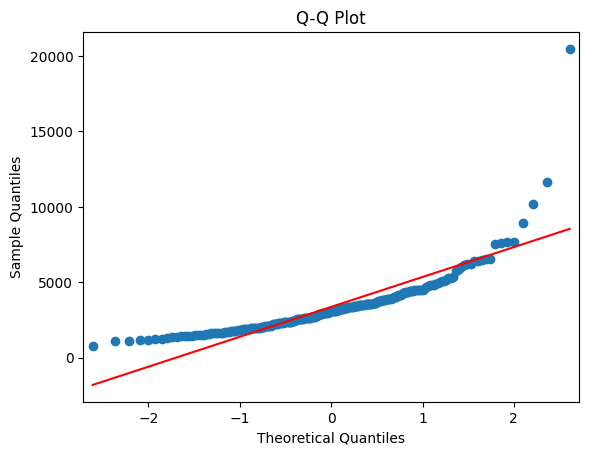

In [21]:
sm.qqplot(amounts, line='s')
plt.title("Q-Q Plot")
plt.show()

## 7. Box-Cox Transformation

In [ ]:
positive = amounts[amounts > 0]
transformed, lam = stats.boxcox(positive)
print(lam)

-0.18083390743966327


## 8. Z-Score & Probability

In [ ]:
z = stats.zscore(amounts)
prob = 1 - stats.norm.cdf(5000, amounts.mean(), amounts.std())
print(prob)

0.20517209567554384


## 9. PDF & CDF

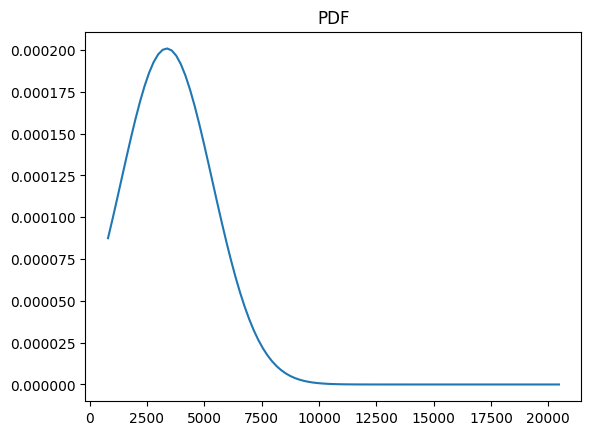

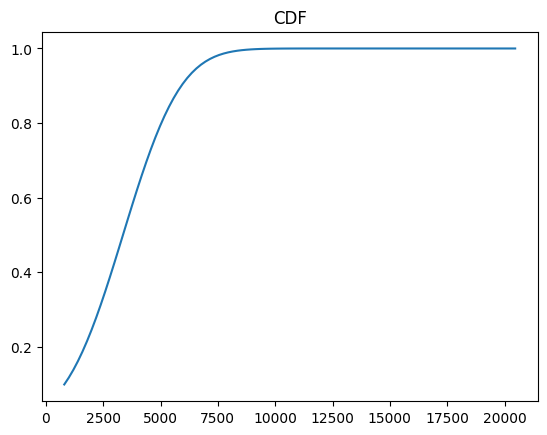

In [ ]:
x = np.linspace(amounts.min(), amounts.max(), 100)

pdf = stats.norm.pdf(x, amounts.mean(), amounts.std())
cdf = stats.norm.cdf(x, amounts.mean(), amounts.std())

plt.plot(x, pdf)
plt.title("PDF")
plt.show()

plt.plot(x, cdf)
plt.title("CDF")
plt.show()

# 🔚 Conclusion

In this analysis, we explored different statistical distributions using the given transaction dataset.

- The **Bernoulli distribution** helped identify the probability of successful transactions.
- The **Binomial distribution** simulated multiple transaction outcomes.
- The **Poisson distribution** modeled the number of transactions per day.
- The **Log-normal and Power law distributions** were used to understand the behavior of transaction amounts.
- The **Q-Q plot** (using statsmodels) helped check whether the data follows a normal distribution.
- The **Box-Cox transformation** improved data normality.
- The **Z-score** identified how far values deviate from the mean.
- The **PDF and CDF** provided a visual understanding of probability distribution.

Overall, this analysis demonstrates how statistical methods can be applied to real-world financial data to gain meaningful insights.